# Customizing Legend Key Size and Appearance

Filled 2D geoms can use `override_aes` to adjust legend key appearance:

- `size` changes the legend key border width.
- `size=0` hides the legend key border.
- `width` and `height` change the relative key size.



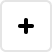
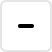
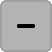
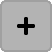
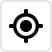
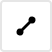
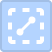
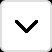
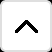
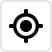
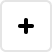
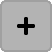
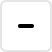
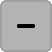
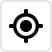
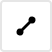
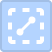
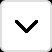
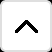
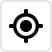

In [1]:
import pandas as pd

from lets_plot import *

LetsPlot.setup_html()

In [2]:
mpg = pd.read_csv('https://raw.githubusercontent.com/JetBrains/lets-plot-docs/refs/heads/master/data/mpg.csv')
mpg.head(3)

,Unnamed: 0,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact


## `size` - Border Stroke Thickness

Each legend key for a filled 2D geom is a filled rectangle drawn with a border.
By default, the border uses the geom's `color` with a fixed width.

In [3]:
# Stacked bar: vehicle class counts broken down by drivetrain type.
p = (
    ggplot(mpg, aes(x='class', fill='drv'))
    + geom_bar(color='black', size=1.6)
    + labs(x='vehicle class', fill='drivetrain')
    + ggsize(580, 340)
)
p + ggtitle('Default legend style')

In [4]:
# Use `size` in `override_aes` to control the legend border thickness. You can make it match the plot.

p + guides(
    fill=guide_legend(
        override_aes={'size': 1.6}
    )
) + ggtitle('Legend key stroke adjusted to match the plot')

In [5]:
# Or you can hide the border completely by setting `size=0` to avoid visual clutter.
    
p + guides(
    fill=guide_legend(
        override_aes={'size': 0}
    )
) + ggtitle('Borderless legend keys')

In [6]:
# Prepare tile data

tile_df = (
    mpg
    .groupby(['class', 'drv'], as_index=False)
    .agg(mean_hwy=('hwy', 'mean'))
)
tile_df['mileage'] = pd.cut(
    tile_df['mean_hwy'],
    bins=[0, 20, 25, 30, 40, 60],
    labels=['up to 20', '20-25', '25-30', '30-40', '40+']
)

base_tile = (
    ggplot(tile_df, aes('class', 'drv', fill='mileage'))
    + geom_tile(color='gray30', size=1.6, width=0.92, height=0.92)
    + scale_fill_brewer(palette='Pastel1')
    + labs(x='vehicle class', y='drive train', fill='mean highway mpg')
    + ggsize(760, 420)
    + theme(axis_text_x=element_text(angle=35, hjust=1))
)

In [7]:
# Some geoms, such as `geom_tile`, have borderless legend keys by default.

base_tile + ggtitle('Default legend keys')

In [8]:
# Adding a contrast border makes the legend colors read closer to the plot.

(
    base_tile
    + guides(
        fill=guide_legend(
            override_aes={'size': 0.8}
        )
    )
    + ggtitle("Legend key border adds visual contrast")
)

## White border

In [9]:
# A white geom border can make legend keys look smaller on a white background.

bar_df = mpg[mpg['class'].isin(['subcompact', 'compact', 'midsize', 'suv', 'pickup'])]

bar_plot = (ggplot(bar_df, aes('class', fill='drv'))
    + geom_bar(size=2.0)
    + scale_fill_brewer(palette='Set2')
    + ggtitle('Bar legend keys with a white border')
    + ggsize(620, 360)
)

bar_plot + guides(
        fill=guide_legend(
            override_aes={'size': 2.0}
        )
    )

In [10]:
# In this case, decreasing `size` makes the visible filled area larger.

bar_plot + guides(
        fill=guide_legend(
            override_aes={'size': 0.5}
        )
    )

## Relative Width and Height

A horizontal legend often reads better with wider, flatter keys. Use `width` and `height` in `override_aes` to change the relative key size.

In [11]:
horizontal_tile = base_tile + theme(legend_position='bottom')

horizontal_tile + ggtitle('Horizontal legend with default key size')

In [12]:
(
    horizontal_tile
    + guides(fill=guide_legend(
        override_aes={'width': 2.5, 'height': 0.8}
    ))
    + ggtitle('Horizontal legend with wider keys')
)

## Different Heights per Category

A list of `height` values can make the legend carry an extra ordered cue. Here, the key height follows engine size: 4, 6, and 8 cylinders.

In [13]:
cylinders = [4, 6, 8]
cylinder_labels = [f'{c} cylinders' for c in cylinders]

cyl_df = mpg[mpg['cyl'].isin(cylinders)].copy()
cyl_df['cylinders'] = pd.Categorical(
    cyl_df['cyl'].map(lambda c: f'{c} cylinders'),
    categories=cylinder_labels,
    ordered=True
)
cyl_df = cyl_df.drop_duplicates(['class', 'cylinders'])

(
    ggplot(cyl_df, aes('class', 'cylinders', fill='cylinders'))
    + geom_tile(color='white', size=0.5, width=0.9, height=0.9)
    + scale_fill_manual(
        values=['chocolate', 'sea_green', 'royal_blue'],
        breaks=cylinder_labels
    )
    + guides(fill=guide_legend(
        override_aes={'height': [0.8, 1.2, 1.6]}                          # <----
    ))
    + labs(x='vehicle class', y='engine size', fill='engine size')
    + ggtitle('Legend key height reflects cylinder count')
    + ggsize(760, 360)
    + theme(axis_text_x=element_text(angle=35, hjust=1), legend_key_spacing=4)
)